In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

# 데이터 로드 및 전처리 (이전 코드와 동일)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WISDM.csv', header=None, comment=';')
df.columns = ['id', 'user', 'activity', 'timestamp', 'x-axis', 'y-axis', 'z-axis']
activities = ['Jogging', 'Sitting']
df_filtered = df[df['activity'].isin(activities)].copy()
df_filtered.loc[:, 'z-axis'] = df_filtered['z-axis'].astype(str).str.replace(';', '').astype(float)
features = ['x-axis', 'y-axis', 'z-axis']
data = df_filtered[features].values
LABELS = ['Sitting', 'Jogging']

# 데이터 정규화 및 클래스 정의
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
df_filtered['true_class'] = df_filtered['activity'].apply(lambda x: 0 if x == 'Sitting' else 1)
y = df_filtered['true_class'].values

# 'Sitting' (정상) 데이터로 학습셋/검증셋 분리
X_normal = data_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
X_test = data_scaled # 전체 데이터

# 오토인코더 모델 구축 및 학습 (이전 코드와 동일)
input_dim = X_train.shape[1]
encoding_dim = 2
input_layer = Input(shape=(input_dim, ))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="linear")(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(X_train, X_train,
                          epochs=20,
                          batch_size=32,
                          shuffle=True,
                          validation_data=(X_val, X_val),
                          verbose=0).history

# 재구성 오류 계산 및 임계값 설정
predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': y})
normal_error = error_df[error_df['true_class'] == 0]['reconstruction_error']
threshold = np.quantile(normal_error, 0.95)
y_pred = [1 if e > threshold else 0 for e in error_df.reconstruction_error.values]

11902/11902 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


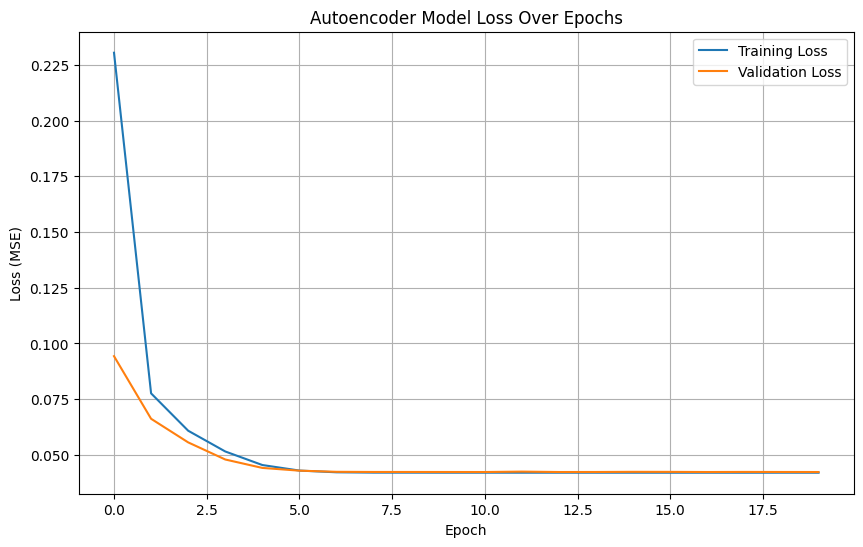

In [3]:
## 2. 학습 손실(Loss) 추이 시각화
plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show() #

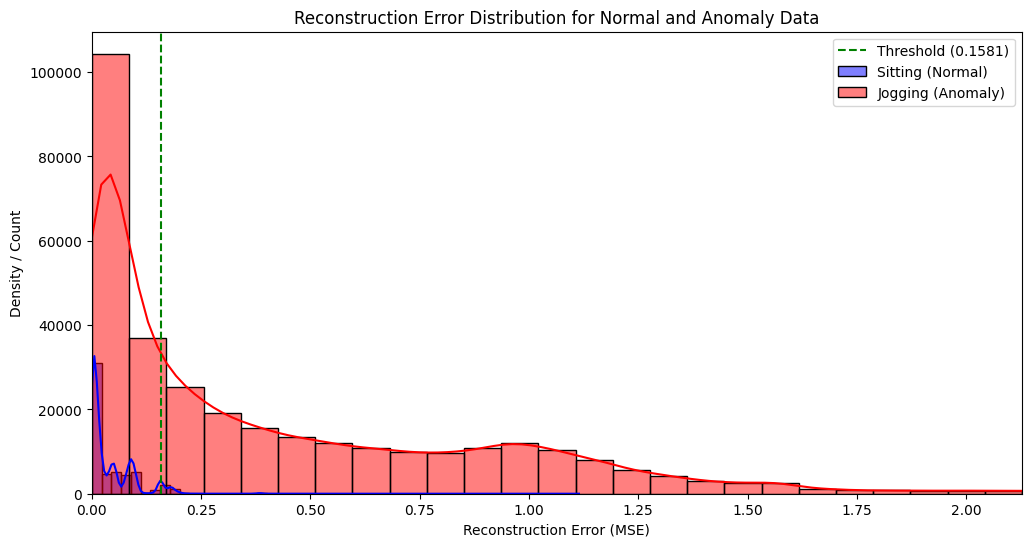

In [4]:
## 3. 재구성 오류 분포 비교 및 임계값 표시
plt.figure(figsize=(12, 6))
sns.histplot(error_df[error_df['true_class'] == 0]['reconstruction_error'], bins=50, kde=True, color='blue', label='Sitting (Normal)')
sns.histplot(error_df[error_df['true_class'] == 1]['reconstruction_error'], bins=50, kde=True, color='red', label='Jogging (Anomaly)')
plt.axvline(threshold, color='green', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.title('Reconstruction Error Distribution for Normal and Anomaly Data')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density / Count')
plt.legend()
plt.xlim([0, error_df['reconstruction_error'].max() * 0.5]) # 분포가 잘 보이도록 x축 제한
plt.show() #

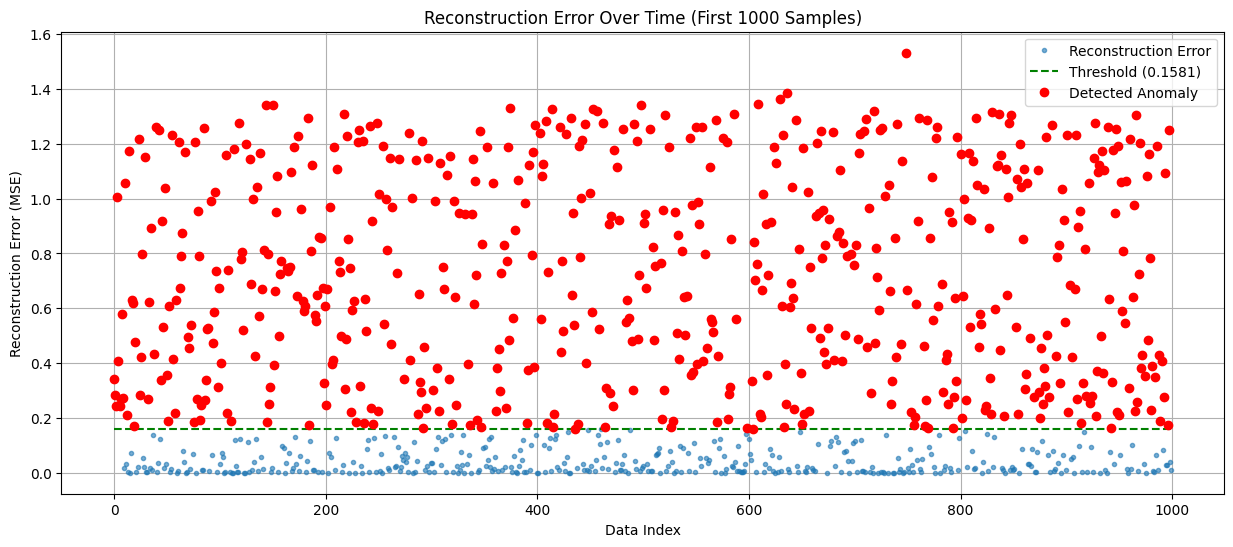

In [5]:
## 4. 재구성 오류 시계열 및 이상치 표시
# 시각화를 위해 처음 1000개의 데이터 포인트만 사용
N = 1000
error_subset = error_df.head(N)

plt.figure(figsize=(15, 6))
plt.plot(error_subset.index, error_subset['reconstruction_error'], marker='.', linestyle='none', label='Reconstruction Error', alpha=0.6)
plt.plot(error_subset.index, [threshold] * N, color='green', linestyle='--', label=f'Threshold ({threshold:.4f})')

# 이상치로 탐지된 포인트만 빨간색으로 표시
anomalies = error_subset[error_subset['reconstruction_error'] > threshold]
plt.plot(anomalies.index, anomalies['reconstruction_error'], marker='o', linestyle='none', color='red', label='Detected Anomaly')

plt.title(f'Reconstruction Error Over Time (First {N} Samples)')
plt.xlabel('Data Index')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(True)
plt.show() #

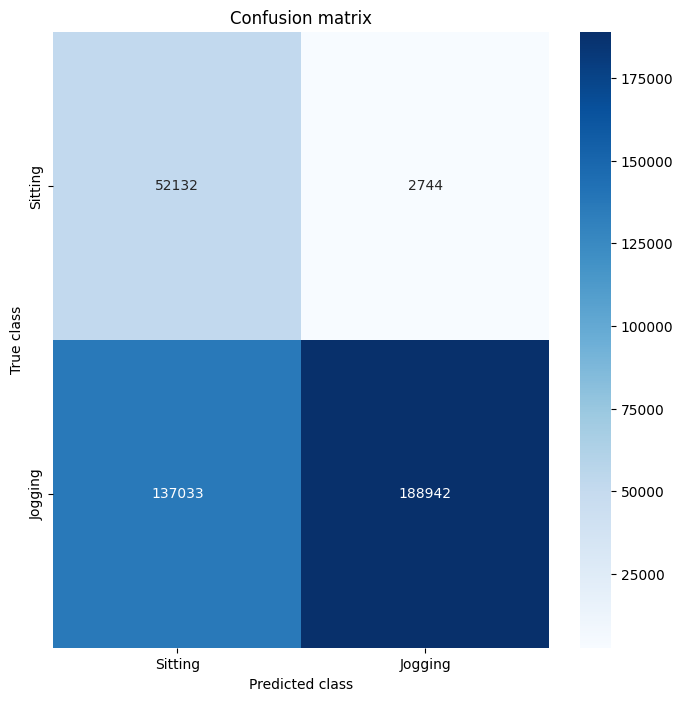


Classification Report
              precision    recall  f1-score   support

     Sitting       0.28      0.95      0.43     54876
     Jogging       0.99      0.58      0.73    325975

    accuracy                           0.63    380851
   macro avg       0.63      0.76      0.58    380851
weighted avg       0.88      0.63      0.69    380851




In [6]:
## 5. 혼동 행렬 시각화 및 분류 보고서 출력 (요청 형식)
conf_matrix = confusion_matrix(error_df.true_class, y_pred)

# 혼동 행렬 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d", cmap='Blues');
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show() #

# 분류 보고서 출력
print("\n" + "=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(error_df.true_class, y_pred, target_names=LABELS))
print("=" * 50 + "\n")